In [1]:
%pip install -e /home/darshan/A6/PCSAFT_cDFT/

import time
notebook_start = time.perf_counter()

import feos, si_units as si, numpy as np, importlib.metadata
from pathlib import Path
from molmass import Formula
import thermoift.PLOT_SETTINGS as ps
import thermoift.FeosPlugin as TC
from thermoift import KIJ
from itertools import combinations

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

Obtaining file:///home/darshan/A6/PCSAFT_cDFT
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.1.0-0.editable-py3-none-any.whl size=3664 sha256=f22a2321f1871dc17f67fc5077a7107d86541ef48d20fb411e1d3186a23a3725
  Stored in directory: /tmp/pip-ephem-wheel-cache-rvpzrtak/wheels/9e/21/12/2dabcfec0ca680013e2c22ad37fea3f18b5f081ec777b70010
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.1.0
    Uninstalling thermoift-0.1.0:
      Successfully uninstalled thermoift-0.1.0
Note: you may need to restart the kernel to use updated packages.
FEOS version used: 0.9.3



K(300.0 K) =
[[ 0.         -0.00395506  0.03481295 -0.02907179  0.05809769]
 [-0.00395506  0.          0.21992654  0.23107175  0.17675567]
 [ 0.03481295  0.21992654  0.         -0.00610567  0.01942321]
 [-0.02907179  0.23107175 -0.00610567  0.          0.03048489]
 [ 0.05809769  0.17675567  0.01942321  0.03048489  0.        ]]

Symbolic K(T) matrix:


Matrix([
[              0,   0.293 - 0.001*T,            0.0348, -0.0291, 0.0664],
[0.293 - 0.001*T,                 0, 0.0002*T + 0.1557,  0.2311, 0.1768],
[         0.0348, 0.0002*T + 0.1557,                 0, -0.0061, 0.0194],
[        -0.0291,            0.2311,           -0.0061,       0, 0.0305],
[         0.0664,            0.1768,            0.0194,  0.0305,      0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0.293 - 0.001*T)

Eq(k_{CO2,Ar}(T), 0.0348)

...

Eq(k_{H2,CH4}(T), 0.1768)

Eq(k_{Ar,N2}(T), -0.0061)

Eq(k_{Ar,CH4}(T), 0.0194)

Eq(k_{N2,CH4}(T), 0.0305)

  i |         z1 |         z2 |         z3 |         z4 |         z5
-------------------------------------------------------------------------------------
  1 |       0.9600       0.0030       0.0070       0.0200       0.0100


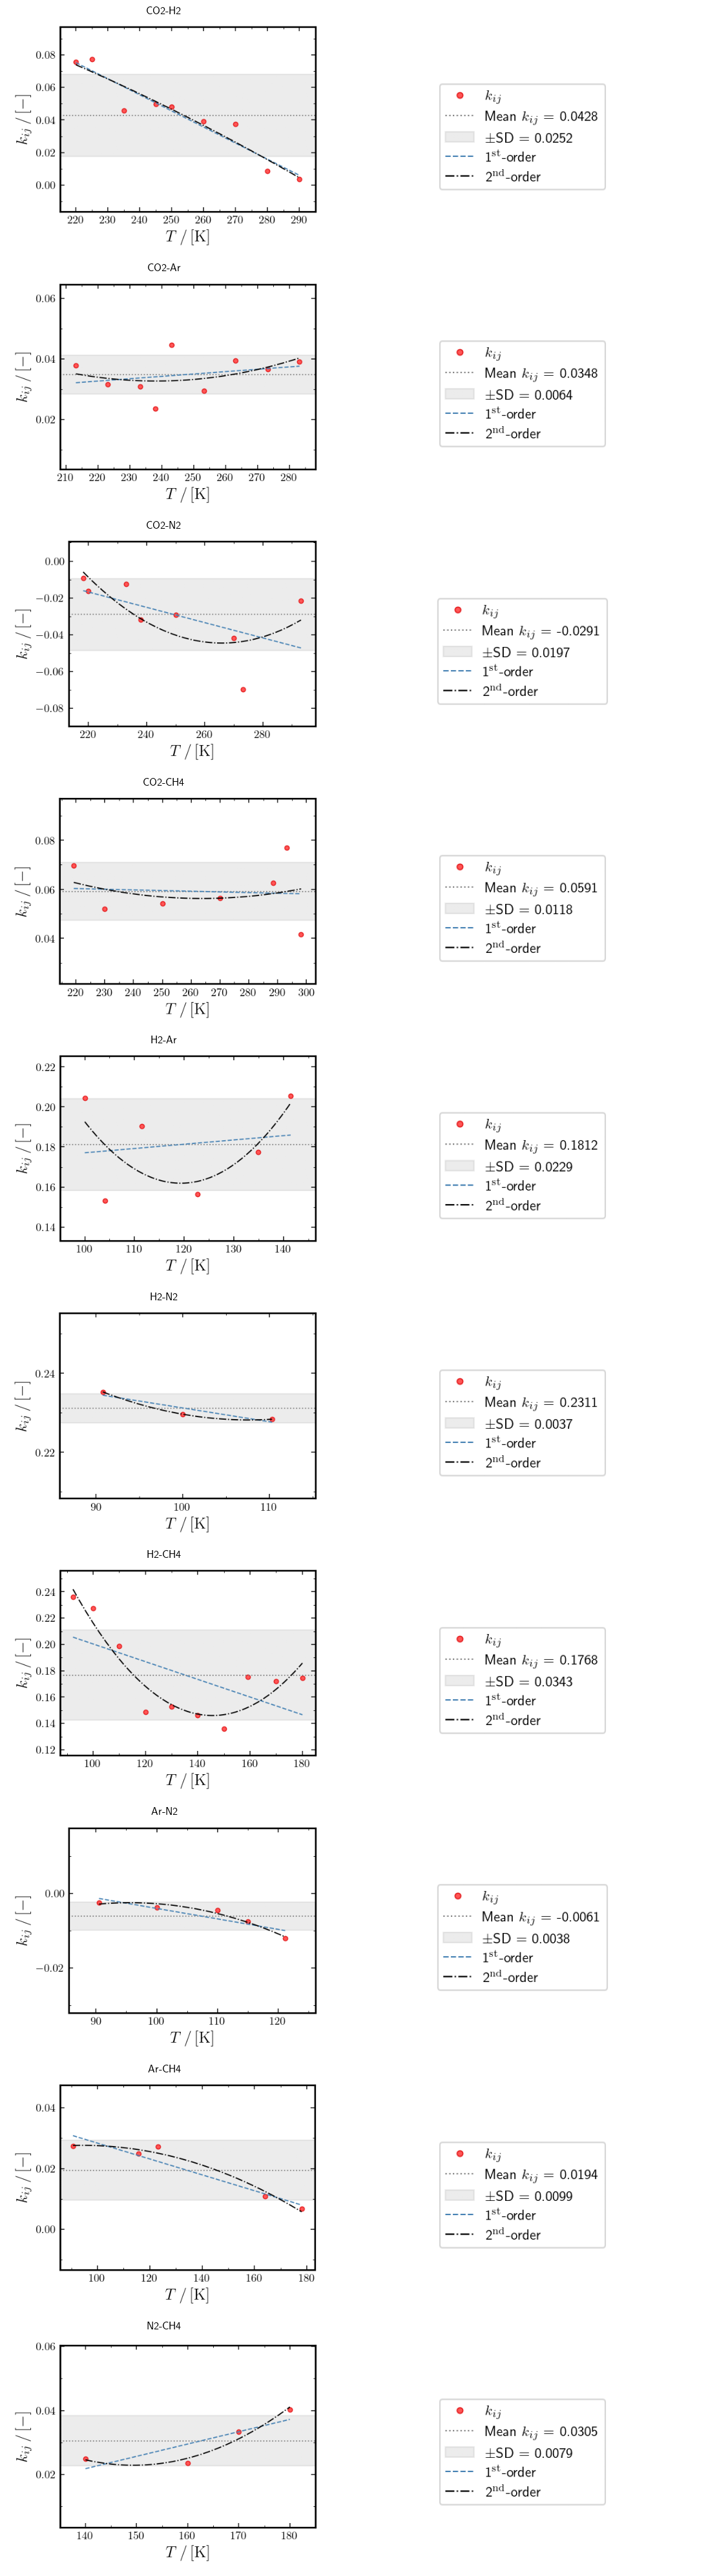

|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|
|hydrogen|2.016|1.0|3.002|51.343|
|argon|39.962|1.0|3.37751|117.80903|
|nitrogen|28.006|1.23831|3.30009|89.41358|
|methane|16.031|1.0|3.70051|150.07147|

|component 1|component 2|k_ij|
|-|-|-|
|carbon dioxide|hydrogen|-0.003955056330330664|
|carbon dioxide|argon|0.03481294797303504|
|carbon dioxide|nitrogen|-0.029071786343496022|
|carbon dioxide|methane|0.058097688976607574|
|hydrogen|argon|0.21992654064301148|
|hydrogen|nitrogen|0.23107174743939032|
|hydrogen|methane|0.17675567238114653|
|argon|nitrogen|-0.00610566808912386|
|argon|methane|0.01942321453247142|
|nitrogen|methane|0.030484885632331253|

In [2]:
COMPONENTS          = ["carbon dioxide", "hydrogen", "argon", "nitrogen", "methane"]
KIJ_map = {
    ("CO2", "H2") : "linear",
    ("CO2", "Ar") : "constant",
    ("H2",  "Ar") : "linear",
    ("CO2", "N2") : "constant",
    ("CO2", "CH4"): "linear",
    ("H2",  "N2") : "constant",
    ("H2",  "CH4"): "constant",
    ("Ar",  "N2") : "constant",
    ("Ar",  "CH4"): "constant",
    ("N2",  "CH4"): "constant",
}
CO2_comp            = 0.96
feeds               = TC.make_feeds([CO2_comp, 0.003, 0.007, 0.020, 0.010])
builder             = KIJ.KIJMatrixBuilder(root = str(KIJ_DIR), kij_filename = "KIJ.json", verbose = False)
parameters          = TC.PARAMETERS(COMPONENTS, T_K= 300.0, kij_builder = builder, model_map = KIJ_map)  # Arbitrary T_K is to check whether KIJ are imported correctly
components          = TC.components(parameters)
KIJ_LABELS          = TC._kij_labels(COMPONENTS)
verbose             = True

builder.build_and_display(
    components          = KIJ_LABELS,
    model_map           = KIJ_map,
    T_eval              = 300.0,
    show_matrix         = True,
    show_pair_equations = True)

TC.print_array2d(feeds)

# FLASH and IFT computation settings
T_initial_guess     = 200
P_TOL               = 1e-4    # Pressure [bar] tolerance for flash calculations excempting at the saturation points
T_STEP              = 1       # Temperature step for bubble/dew curve calculations (K)
P_STEP              = 1       # Pressure step for flash calculations (bar)
PT_results          = {}
VLE_DFT             = {}
lgrid               = 100    # Length of the computational domain for the planar interface in Angstroms
ngrid               = 2048     # number of grid points required for the planar interface computation

# To plot all pair KIJ curves
# for c1, c2 in combinations(KIJ_LABELS, 2):
#     builder.show_pair_plot(c1, c2, mode="all")

builder.show_pair_plots(TC._kij_labels(COMPONENTS), mode="all")

parameters

In [ ]:
# # TEST ---- FLASH and IFT computation settings
# T_initial_guess     = 200
# P_TOL               = 1e-2    # Pressure [bar] tolerance for flash calculations excempting at the saturation points
# T_STEP              = 10       # Temperature step for bubble/dew curve calculations (K)
# P_STEP              = 5       # Pressure step for flash calculations (bar)
# PT_results          = {}
# VLE_DFT             = {}
# lgrid               = 100    # Length of the computational domain for the planar interface in Angstroms
# ngrid               = 500     # number of grid points required for the planar interface computation

In [ ]:
# ── Parameters & EOS (T-dependent kij rebuilt per temperature) ─────────────

for k, z in enumerate(feeds, start=1):
    
    # --- normalize + mole amounts ---
    z    = TC.normalize_z(z)
    feed = TC.compute_feed_moles(z)
    
    if verbose:
        print(f"\nFeed {k}: z = {z}") 
    
    # --- detect zero components and reduce if one of the component is zero ---
    active_z, active_components, is_reduced = TC.reduce_components(z, COMPONENTS, verbose=verbose)
    active_feed                             = TC.compute_feed_moles(active_z)
    active_map                              = TC.reduce_kij_map(active_components, KIJ_map)  
    
    # --- critical point (use a reference T for kij) ---
    parameters_ref  = TC.PARAMETERS(active_components,T_K = T_initial_guess, kij_builder = builder, model_map = active_map)
    eos             = feos.HelmholtzEnergyFunctional.pcsaft(parameters_ref)
    
    try:
        CT, CP = TC.compute_CT(feos, eos, active_z*si.MOL, T_guess=T_initial_guess)
        
        if verbose:
            print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")
    
        # ---- compute bubble and dew curves with T-dependent kij ----
        T_values       = range(int(T_initial_guess), int(CT / si.KELVIN) + 1, T_STEP)
        bubble_results = []
        dew_results    = []

        T_bubble_all, P_bubble_all = [], []
        T_dew_all,    P_dew_all    = [], []

        for T_K in T_values:
            # Rebuild parameters and eos at each temperature
            parameters_T = TC.PARAMETERS(active_components,T_K = float(T_K),kij_builder = builder, model_map = active_map)
            eos_T = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)

            T_bub, P_bub = TC.compute_bubble_curve(eos_T, [T_K], active_feed, verbose=verbose)
            T_dew, P_dew = TC.compute_dew_curve(eos_T,    [T_K], active_feed, verbose=verbose)

            T_bubble_all.extend(T_bub); P_bubble_all.extend(P_bub)
            T_dew_all.extend(T_dew);    P_dew_all.extend(P_dew)

        PT_results[f"feed_{k}"] = {
            "z":       [round(float(x), 6) for x in np.asarray(z, dtype=float)],
            "TC_K":    round(float(CT / si.KELVIN), 2),
            "PC_bar":  round(float(CP / si.BAR), 2),
            "bubble":  [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble_all, P_bubble_all)],
            "dew":     [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_all, P_dew_all)],
        }
    
    except Exception as e:
        print(f"Feed {k}: z = {z}")
        print("CT computation failed:", e)

In [ ]:
######################## PT phase digram spcae sweep , TP flash, and cDFT computations #################
for feed_key, feed in PT_results.items():

    TP_z = np.array(feed.get("z", []))
    CT   = feed["TC_K"] * si.KELVIN
    
    # --- detect zero components and reduce if one of the component is zero ---
    active_z, active_components, is_reduced = TC.reduce_components(TP_z, COMPONENTS, verbose=verbose)
    active_feed                             = TC.compute_feed_moles(active_z)
    active_map                              = TC.reduce_kij_map(active_components, KIJ_map)
    
    fig, ax     = TC.plot_PT(PT_results, feed_key, parameters)
    
    bub         = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("bubble", [])}
    dew         = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("dew", [])}
    common_T    = sorted(set(bub) & set(dew))

    # ---- Initialize unified storage for this FIXED feed composition ----
    VLE_DFT[feed_key] = {
        "z": TP_z.tolist(),
        "phase_envelope": {
            "bubble_curve": [{"T_K": T, "P_bar": bub[T]} for T in sorted(bub.keys())],
            "dew_curve": [{"T_K": T, "P_bar": dew[T]} for T in sorted(dew.keys())],
            "isothermal_lines": [
                {"T_K": T, "P_bubble_bar": bub[T], "P_dew_bar": dew[T]} 
                for T in common_T
            ]
        },
        "interfacial_data": {}
    }
    
    if verbose:
        print(f"\n{feed_key}:")
        for T in common_T:
            print(f"  T = {T} K: P_bubble = {bub[T]:.2f} bar, P_dew = {dew[T]:.2f} bar")
    
    if common_T:
        
        for T in common_T:    
            
            # Rebuild parameters and eos at this temperature
            parameters_T        = TC.PARAMETERS(active_components, T_K = float(T), kij_builder = builder, model_map = active_map)
            eos_T               = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
            molar_masses        = TC.molar_masses(parameters_T) # g/mol
            
            P_b = bub[T]
            P_d = dew[T]

            if P_b >= P_d:
                
                pressures = np.linspace(P_d + P_TOL, P_b - P_TOL, 10)
                
                # ---- optional: PLOT ----
                ax.plot([T, T], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)
                
                # Initialize list for this temperature
                VLE_DFT[feed_key]["interfacial_data"][T] = []
                
                for P in pressures:
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} | z = {active_z}")
                       
                    # --- TP flash ---
                    try:
                        eq, x, y, liquid_density, vapor_density = TC.tp_flash(
                            feos, eos_T, T*si.KELVIN, P*si.BAR, active_z*si.MOL, molar_masses)
                    except Exception as e:
                        print(f"TP flash failed for z = {active_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        continue
                    
                    # --- planar interface & surface tension ---
                    interface = TC.build_planar_interface(
                        eq, critical_temperature=CT, n_grid=ngrid, l_grid=lgrid)
                    
                    try:
                        gamma_mN_m, interfacial_thickness_nm, enrichment = \
                            TC.solve_interface_properties(interface, si)
                    except Exception as e:
                        print(f"Surface tension calculation failed for z = {active_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        gamma_mN_m = np.nan
                        interfacial_thickness_nm = np.nan
                        enrichment = tuple(np.nan for _ in active_components)
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

                    # ---- Use TC.row_append for consistent formatting ----
                    row_data = TC.row_append(
                        x, y, liquid_density, vapor_density, 
                        CT, gamma_mN_m, interfacial_thickness_nm, 
                        active_components, enrichment)
                    
                    # Add T and P to the row
                    row_data["T_K"] = float(T)
                    row_data["P_bar"] = float(P)
                    
                    # Store in interfacial_data
                    VLE_DFT[feed_key]["interfacial_data"][T].append(row_data)
                    
    TC.save_plot(fig, f"PT_{feed_key}")
    
    fig_gamma = TC.plot_gamma_colormap(PT_results, VLE_DFT, feed_key, parameters)
    if fig_gamma is not None:
        ps.save_plot(fig_gamma, f"Gamma_{feed_key}")

summary = TC.VLE_DFT_summary(VLE_DFT)

if verbose:
    print(summary)
  
saved_files = TC.VLE_DFT_to_csv(VLE_DFT, verbose=verbose)

In [ ]:
notebook_end    = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")